In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# 1. Carga de datos
df = pd.read_csv('df_long.csv')

=== TABLA DE DATOS: PROMEDIOS POR GRUPO NDC ===
Grupo NDC Tratamiento  N (Sujetos)  Media  Desv. Estándar
 High NDC         CON           48  0.375           0.314
 High NDC        DIST           48  0.358           0.298
 High NDC         SIN           48  0.396           0.348
  Low NDC         CON           70  0.395           0.234
  Low NDC        DIST           70  0.360           0.232
  Low NDC         SIN           70  0.393           0.241


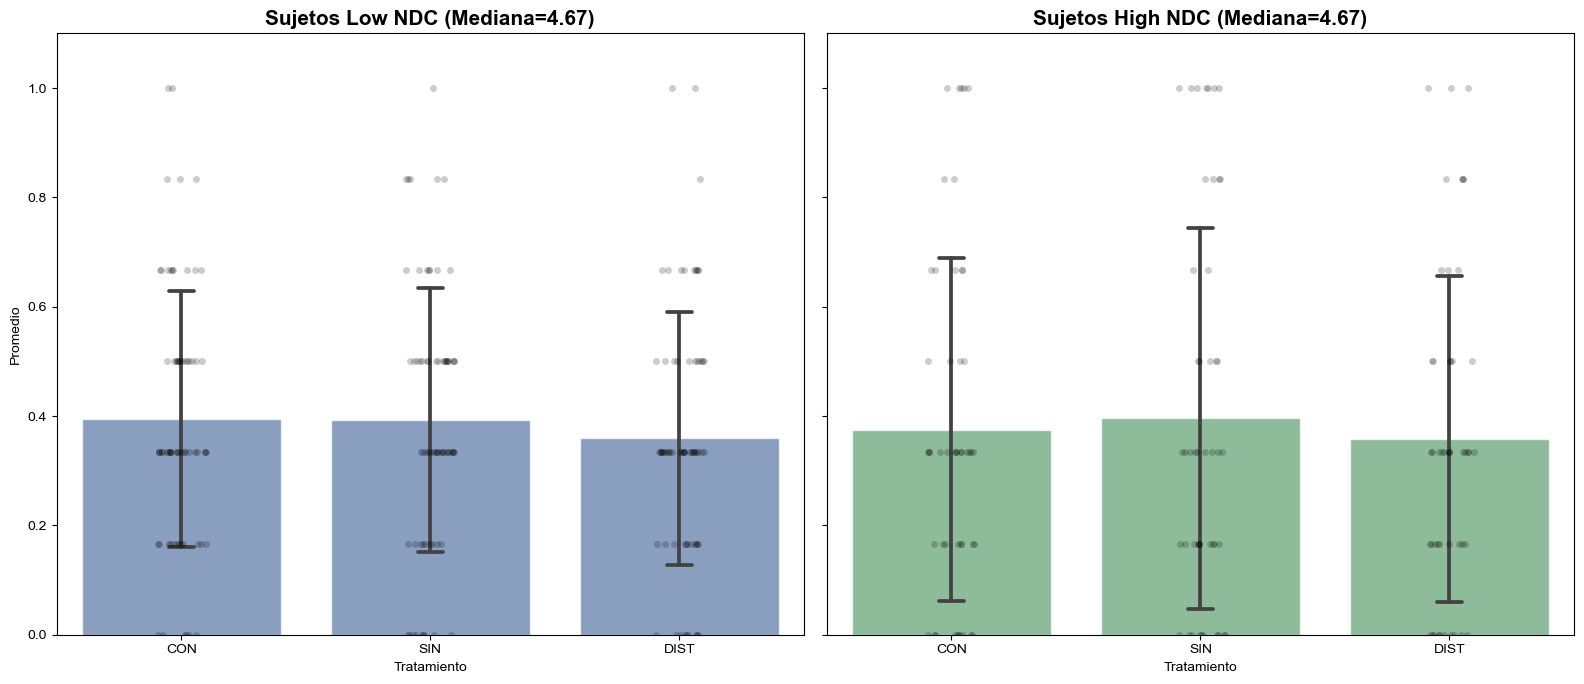

In [5]:
cols_promedio = ['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST']
df_u = df.drop_duplicates(subset=['ID_Sujeto'])[['ID_Sujeto', 'NDC_Score'] + cols_promedio]

# 2. Dividir grupos NDC por la mediana
median_ndc = df_u['NDC_Score'].median()
df_u['NDC_Group'] = df_u['NDC_Score'].apply(lambda x: 'High NDC' if x > median_ndc else 'Low NDC')

# 3. Transformar a formato largo para el análisis
df_plot = df_u.melt(id_vars=['ID_Sujeto', 'NDC_Group'], 
                    value_vars=cols_promedio,
                    var_name='Tratamiento', value_name='Promedio')
df_plot['Tratamiento'] = df_plot['Tratamiento'].str.replace('Promedio_', '')

# 4. GENERAR E IMPRIMIR LA TABLA RESUMEN
tabla_resumen = df_plot.groupby(['NDC_Group', 'Tratamiento'])['Promedio'].agg(['count', 'mean', 'std']).reset_index()
tabla_resumen.columns = ['Grupo NDC', 'Tratamiento', 'N (Sujetos)', 'Media', 'Desv. Estándar']
# Ordenar para claridad
tabla_resumen = tabla_resumen.sort_values(by=['Grupo NDC', 'Tratamiento'])

print("=== TABLA DE DATOS: PROMEDIOS POR GRUPO NDC ===")
print(tabla_resumen.round(3).to_string(index=False))

# 5. Crear los dos gráficos en una fila
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set_theme(style="whitegrid")

grupos = ['Low NDC', 'High NDC']
colores = ['#4c72b0', '#55a868'] # Azul para Low, Verde para High

for i, grupo in enumerate(grupos):
    data_g = df_plot[df_plot['NDC_Group'] == grupo]
    
    # Dibujar barras con media y desviación estándar
    sns.barplot(ax=axes[i], data=data_g, x='Tratamiento', y='Promedio', 
                order=['CON', 'SIN', 'DIST'], errorbar='sd', capsize=.1, color=colores[i], alpha=0.7)
    
    # Agregar puntos individuales para ver la dispersión real
    sns.stripplot(ax=axes[i], data=data_g, x='Tratamiento', y='Promedio', 
                  order=['CON', 'SIN', 'DIST'], color='black', alpha=0.2, jitter=True)
    
    axes[i].set_title(f'Sujetos {grupo} (Mediana={median_ndc:.2f})', fontsize=15, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Promedio' if i == 0 else "")

plt.tight_layout()
plt.show()

In [6]:
# Calcular la mediana del NDC basada en sujetos únicos 
median_ndc = df.drop_duplicates('ID_Sujeto')['NDC_Score'].median()

# 3. Identificar a los grupos y filtrar solo los "High NDC"
# Se consideran "High NDC" aquellos con un score mayor a la mediana
df_high_ndc = df[df['NDC_Score'] > median_ndc].copy()

# 4.Guardar el nuevo DataFrame en un archivo CSV
df_high_ndc.to_csv('df_high_ndc.csv', index=False)

# Verificar el resultado
print(f"Sujetos totales en el nuevo DF: {df_high_ndc['ID_Sujeto'].nunique()}")

Sujetos totales en el nuevo DF: 48


In [7]:
# 4. Crear el dataframe final
df_expectativas_ndc = df_expectativas[df_expectativas['NDC_Group'] == 'High NDC'].copy()
# Verificar el resultado
print(f"Sujetos totales en el nuevo DF: {df_expectativas_ndc['ID_Sujeto'].nunique()}")
# 4.Guardar el nuevo DataFrame en un archivo CSV
df_expectativas_ndc.to_csv('df_expectativas_ndc.csv', index=False)

NameError: name 'df_expectativas' is not defined